# Fall Detection — FCOS + MobileNetV3

**FCOS (Fully Convolutional One-Stage Object Detection)** with a MobileNetV3-Small backbone.

## How FCOS Works

Unlike grid-based detectors that predict `(cx, cy, w, h)` relative to anchor boxes or grid cells,
FCOS treats **every spatial location** in the feature map as a potential detection point and predicts
the **distances to the four sides** of the nearest ground-truth box:

```
For a point (x, y) inside a GT box:
  l = x - x1   (distance to left edge)
  t = y - y1   (distance to top edge)
  r = x2 - x   (distance to right edge)
  b = y2 - y   (distance to bottom edge)
```

Each location also predicts a **centerness score** — how close it is to the object centre:
```
centerness = sqrt( min(l,r)/max(l,r) * min(t,b)/max(t,b) )
```
Locations near the centre score close to 1.0; edge locations score near 0.0.
This naturally suppresses low-quality boxes without needing anchor tuning.

## Architecture
```
Input [3, 224, 224]
  └─► MobileNetV3-Small backbone  (ImageNet pretrained)
        └─► Feature map  [96, 14, 14]      (from block 9, stride-16)
              └─► FCOS Head  (shared conv tower)
                    ├─► Classification branch  → [C, 14, 14]   sigmoid
                    ├─► Regression branch      → [4, 14, 14]   exp(x) * stride
                    └─► Centerness branch      → [1, 14, 14]   sigmoid
```

## Output per location
- **C class scores** (one per class, sigmoid)
- **4 box distances** (l, t, r, b — positive values)
- **1 centerness** (0–1, quality score)

## Classes
**0** = fall_detected | **1** = walk | **2** = sit

## 0. Imports & Configuration

In [1]:
import os, random, shutil, time, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.transforms import functional as TF
from torchvision import models

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR  = Path('../dataset/fall_dataset')
IMG_DIR   = BASE_DIR / 'images'
LABEL_DIR = BASE_DIR / 'labels'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   : {DEVICE}')
print(f'Platform : {platform.system()}')

# ── Image & FCOS hyperparameters ──────────────────────────────────────────────
IMG_SIZE    = 224 if not torch.cuda.is_available() else 448
NUM_CLASSES = 3
STRIDE      = 16     # MobileNetV3 block-9 downsamples by 16×
                     # → feature map is IMG_SIZE/STRIDE = 14×14 locations

CLASS_NAMES  = ['fall_detected', 'walk', 'sit']
CLASS_TO_IDX = {n: i for i, n in enumerate(CLASS_NAMES)}

# Fall class weighted 3× — penalise missed falls harder
CLASS_WEIGHTS = torch.tensor([3.0, 1.0, 1.0]).to(DEVICE)

# ── DataLoader config ─────────────────────────────────────────────────────────
IS_WINDOWS  = platform.system() == 'Windows'
NUM_WORKERS = 0 if IS_WINDOWS else 2
PIN_MEMORY  = torch.cuda.is_available()

FEAT_H = IMG_SIZE // STRIDE   # feature map height (14 for 224 input)
FEAT_W = IMG_SIZE // STRIDE   # feature map width

print(f'IMG_SIZE     : {IMG_SIZE}')
print(f'Stride       : {STRIDE}  →  feature map: {FEAT_H}×{FEAT_W} = {FEAT_H*FEAT_W} locations')
print(f'num_workers  : {NUM_WORKERS}  |  pin_memory: {PIN_MEMORY}')

Device   : cpu
Platform : Windows
IMG_SIZE     : 224
Stride       : 16  →  feature map: 14×14 = 196 locations
num_workers  : 0  |  pin_memory: False


## 1. Merge val → train & Audit

In [2]:
for folder in ['images', 'labels']:
    src = BASE_DIR / folder / 'val'
    dst = BASE_DIR / folder / 'train'
    dst.mkdir(parents=True, exist_ok=True)
    for f in src.iterdir():
        dest = dst / f.name
        if not dest.exists():
            shutil.copy(f, dest)
print('Val merged into train.')

def audit_labels(split):
    label_path = LABEL_DIR / split
    class_counts = Counter()
    n_images     = 0
    for txt in label_path.glob('*.txt'):
        n_images += 1
        for line in open(txt):
            parts = line.strip().split()
            if len(parts) >= 5:
                class_counts[int(parts[0])] += 1
    print(f'[{split}]  images={n_images}  '
          f'instances={ {CLASS_NAMES[k]: v for k,v in sorted(class_counts.items())} }')
    return class_counts

audit_labels('train')
audit_labels('val')

Val merged into train.
[train]  images=538  instances={'fall_detected': 271, 'walk': 320, 'sit': 255}
[val]  images=111  instances={'fall_detected': 72, 'walk': 23, 'sit': 19}


Counter({0: 72, 1: 23, 2: 19})

## 2. Letterbox Resize

In [3]:
class LetterboxResize:
    """
    Resize preserving aspect ratio, pad remainder with 114 (neutral grey).
    Critical for FCOS: the (l,t,r,b) regression targets depend on
    correct spatial positioning — squishing would corrupt them.
    """
    def __init__(self, size: int):
        self.size = size

    def __call__(self, img: Image.Image):
        W, H   = img.size
        scale  = self.size / max(W, H)
        new_W, new_H = int(W * scale), int(H * scale)
        img    = TF.resize(img, (new_H, new_W))
        pl = (self.size - new_W) // 2
        pt = (self.size - new_H) // 2
        pr = self.size - new_W - pl
        pb = self.size - new_H - pt
        return TF.pad(img, (pl, pt, pr, pb), fill=114)

## 3. Dataset — FCOS Target Generation

For each spatial location `(i, j)` in the feature map:
1. Map it back to image coordinates: `x = (j + 0.5) * stride`, `y = (i + 0.5) * stride`
2. Check if `(x, y)` falls **inside** any GT box
3. If yes: compute `(l, t, r, b)` distances + centerness + class label
4. If multiple GT boxes contain the point: assign the **smallest area** box
   (so fine-grained details aren't lost to large surrounding boxes)

In [4]:
class FCOSDataset(Dataset):
    """
    Generates FCOS regression targets per spatial location.

    Target tensors per image:
      cls_target  : [FEAT_H, FEAT_W]          int64  — class id (-1 = background)
      reg_target  : [FEAT_H, FEAT_W, 4]       float  — (l, t, r, b) in pixels
      ctr_target  : [FEAT_H, FEAT_W]          float  — centerness score 0–1
      pos_mask    : [FEAT_H, FEAT_W]          bool   — True where location is positive
    """
    def __init__(self, split, img_size=224, stride=16, augment=False):
        self.img_dir   = IMG_DIR / split
        self.label_dir = LABEL_DIR / split
        self.img_size  = img_size
        self.stride    = stride
        self.feat_h    = img_size // stride
        self.feat_w    = img_size // stride
        self.augment   = augment

        self.img_files = sorted(
            list(self.img_dir.glob('*.jpg')) +
            list(self.img_dir.glob('*.png'))
        )

        self.normalize = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )
        self.base_tf = T.Compose([LetterboxResize(img_size), T.ToTensor()])
        self.aug_tf  = T.Compose([
            LetterboxResize(img_size),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
            T.RandomGrayscale(p=0.05),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.img_files)

    def get_label_classes(self, idx):
        """Used by the weighted sampler."""
        txt = self.label_dir / (self.img_files[idx].stem + '.txt')
        classes = []
        if txt.exists():
            for line in open(txt):
                p = line.strip().split()
                if len(p) >= 5:
                    classes.append(int(p[0]))
        return classes

    def _load_boxes(self, img_path):
        """Load GT boxes as pixel coords [x1,y1,x2,y2] + class."""
        txt  = self.label_dir / (img_path.stem + '.txt')
        boxes = []
        if txt.exists():
            for line in open(txt):
                p = line.strip().split()
                if len(p) < 5:
                    continue
                cls = int(p[0])
                cx, cy, bw, bh = map(float, p[1:5])
                # Convert normalised → pixel coords in IMG_SIZE space
                x1 = (cx - bw/2) * self.img_size
                y1 = (cy - bh/2) * self.img_size
                x2 = (cx + bw/2) * self.img_size
                y2 = (cy + bh/2) * self.img_size
                boxes.append((cls, x1, y1, x2, y2))
        return boxes

    def _build_targets(self, boxes):
        """
        Build FCOS targets for all (FEAT_H × FEAT_W) locations.
        """
        H, W   = self.feat_h, self.feat_w
        S      = self.stride

        cls_target = torch.full((H, W), -1, dtype=torch.long)   # -1 = bg
        reg_target = torch.zeros(H, W, 4)                        # l, t, r, b
        ctr_target = torch.zeros(H, W)
        pos_mask   = torch.zeros(H, W, dtype=torch.bool)

        for row in range(H):
            for col in range(W):
                # Centre of this feature map location in image pixels
                px = (col + 0.5) * S
                py = (row + 0.5) * S

                # Find all GT boxes that contain this point
                candidates = []
                for (cls, x1, y1, x2, y2) in boxes:
                    if x1 < px < x2 and y1 < py < y2:
                        area = (x2 - x1) * (y2 - y1)
                        candidates.append((area, cls, x1, y1, x2, y2))

                if not candidates:
                    continue   # background location

                # Assign to smallest-area box (FCOS standard)
                _, cls, x1, y1, x2, y2 = min(candidates, key=lambda c: c[0])

                l = px - x1
                t = py - y1
                r = x2 - px
                b = y2 - py

                # Centerness: sqrt( min(l,r)/max(l,r) * min(t,b)/max(t,b) )
                ctr = ((min(l,r) / (max(l,r) + 1e-6)) *
                       (min(t,b) / (max(t,b) + 1e-6))) ** 0.5

                cls_target[row, col] = cls
                reg_target[row, col] = torch.tensor([l, t, r, b])
                ctr_target[row, col] = ctr
                pos_mask[row, col]   = True

        return cls_target, reg_target, ctr_target, pos_mask

    def __getitem__(self, idx):
        img_path   = self.img_files[idx]
        img        = Image.open(img_path).convert('RGB')
        img_tensor = (self.aug_tf if self.augment else self.base_tf)(img)
        img_tensor = self.normalize(img_tensor)

        boxes = self._load_boxes(img_path)
        cls_t, reg_t, ctr_t, pos_m = self._build_targets(boxes)

        return img_tensor, cls_t, reg_t, ctr_t, pos_m


# Sanity check
ds_check = FCOSDataset('train', IMG_SIZE, STRIDE)
img_t, cls_t, reg_t, ctr_t, pos_m = ds_check[0]
print(f'Image   : {img_t.shape}')
print(f'cls_tgt : {cls_t.shape}   unique={cls_t.unique().tolist()}')
print(f'reg_tgt : {reg_t.shape}')
print(f'ctr_tgt : {ctr_t.shape}   range=[{ctr_t.min():.2f}, {ctr_t.max():.2f}]')
print(f'pos_mask: {pos_m.shape}   positive locations={pos_m.sum().item()}')

Image   : torch.Size([3, 224, 224])
cls_tgt : torch.Size([14, 14])   unique=[-1, 0]
reg_tgt : torch.Size([14, 14, 4])
ctr_tgt : torch.Size([14, 14])   range=[0.00, 0.79]
pos_mask: torch.Size([14, 14])   positive locations=18


In [5]:
# ── Datasets & DataLoaders ────────────────────────────────────────────────────
train_dataset = FCOSDataset('train', IMG_SIZE, STRIDE, augment=True)
val_dataset   = FCOSDataset('val',   IMG_SIZE, STRIDE, augment=False)
print(f'Train: {len(train_dataset)}  |  Val: {len(val_dataset)}')

# Weighted sampler: images with falls sampled 3× more often
sample_weights = [
    3.0 if 0 in train_dataset.get_label_classes(i) else 1.0
    for i in range(len(train_dataset))
]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=8, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=False)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=False)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train: 559  |  Val: 111
Train batches: 70  |  Val batches: 14


## 4. Model — MobileNetV3 Backbone + FCOS Head

### Backbone feature extraction
MobileNetV3-Small has 13 feature blocks. We extract from **block 9** which gives
a stride-16 feature map (14×14 for 224px input) with 96 channels — a good
balance of receptive field and spatial resolution for person-scale objects.

### FCOS Head — three branches
```
Shared conv tower (4× Conv-BN-ReLU)
      ├─► Classification branch  →  C sigmoid outputs  (one per class)
      ├─► Regression branch      →  4 exp() outputs    (l, t, r, b distances)
      └─► Centerness branch      →  1 sigmoid output   (quality score)
```
All three branches share the same feature tower — this forces the model to
learn representations that serve localisation, classification, and quality estimation jointly.

In [6]:
class MobileNetV3Backbone(nn.Module):
    """
    MobileNetV3-Small feature extractor.
    Dynamically finds the correct number of blocks to produce
    a stride-16 (14x14 for 224px input) feature map.
    """
    def __init__(self, freeze_early=True):
        super().__init__()
        mob = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )

        # Find how many blocks give us stride-16 output
        # by running a dummy forward pass through increasing numbers of blocks
        dummy   = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
        n_blocks = len(mob.features)
        cut_idx  = n_blocks  # fallback: use all blocks

        with torch.no_grad():
            for n in range(1, n_blocks + 1):
                out = nn.Sequential(*list(mob.features.children())[:n])(dummy)
                fh, fw = out.shape[2], out.shape[3]
                # Stop as soon as we hit the target feature map size
                if fh == FEAT_H and fw == FEAT_W:
                    cut_idx = n
                    print(f'  Backbone: using first {n} blocks → '
                          f'output [{out.shape[1]}, {fh}, {fw}]')
                    break
                if fh < FEAT_H:
                    # Gone too far — use previous block count
                    cut_idx = max(n - 1, 1)
                    out2 = nn.Sequential(
                        *list(mob.features.children())[:cut_idx]
                    )(dummy)
                    print(f'  Backbone: using first {cut_idx} blocks → '
                          f'output [{out2.shape[1]}, {out2.shape[2]}, {out2.shape[3]}]')
                    break

        self.features   = nn.Sequential(*list(mob.features.children())[:cut_idx])
        self.out_channels = out.shape[1]

        if freeze_early:
            for i, block in enumerate(self.features):
                if i < 4:
                    for p in block.parameters():
                        p.requires_grad = False

    def forward(self, x):
        return self.features(x)


class ConvBNReLU(nn.Module):
    """Standard Conv → BatchNorm → ReLU block used in FCOS head tower."""
    def __init__(self, in_ch, out_ch, kernel=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class FCOSHead(nn.Module):
    """
    FCOS detection head with three output branches.

    Inputs : feature map  [B, in_channels, H, W]
    Outputs:
      cls_logits  [B, C, H, W]  — raw class scores (apply sigmoid for probs)
      reg_pred    [B, 4, H, W]  — box distances (l,t,r,b) via exp()
      ctr_logits  [B, 1, H, W]  — centerness (apply sigmoid)
    """
    def __init__(self, in_channels=96, num_classes=3, tower_channels=128,
                 num_tower_layers=4):
        super().__init__()
        self.num_classes = num_classes

        # Shared feature tower
        tower = [ConvBNReLU(in_channels, tower_channels)]
        for _ in range(num_tower_layers - 1):
            tower.append(ConvBNReLU(tower_channels, tower_channels))
        self.tower = nn.Sequential(*tower)

        # Classification branch
        self.cls_branch = nn.Conv2d(tower_channels, num_classes, 1)

        # Regression branch
        # exp() is applied in forward() to ensure positive (l,t,r,b) values
        self.reg_branch = nn.Conv2d(tower_channels, 4, 1)

        # Centerness branch (shares tower with cls)
        self.ctr_branch = nn.Conv2d(tower_channels, 1, 1)

        # Learnable scale per output (standard FCOS trick for stable reg)
        self.scale = nn.Parameter(torch.ones(1))

        self._init_weights()

    def _init_weights(self):
        # Bias init: prior probability for classification ≈ 0.01
        # avoids large loss at init from confident wrong predictions
        prior = 0.01
        nn.init.constant_(self.cls_branch.bias,
                          -np.log((1 - prior) / prior))
        nn.init.normal_(self.reg_branch.weight, std=0.01)
        nn.init.constant_(self.reg_branch.bias, 0)
        nn.init.normal_(self.ctr_branch.weight, std=0.01)
        nn.init.constant_(self.ctr_branch.bias, 0)

    def forward(self, x):
        feat       = self.tower(x)                          # [B, 128, H, W]
        cls_logits = self.cls_branch(feat)                  # [B, C,   H, W]
        reg_pred   = torch.exp(self.scale * self.reg_branch(feat))  # [B, 4, H, W] positive
        ctr_logits = self.ctr_branch(feat)                  # [B, 1,   H, W]
        return cls_logits, reg_pred, ctr_logits


class FCOSDetector(nn.Module):
    def __init__(self, num_classes=3, freeze_early=True,
                 tower_channels=128, num_tower_layers=4):
        super().__init__()
        self.backbone = MobileNetV3Backbone(freeze_early=freeze_early)
        self.head     = FCOSHead(
            in_channels      = self.backbone.out_channels,  # ← dynamic, not hardcoded
            num_classes      = num_classes,
            tower_channels   = tower_channels,
            num_tower_layers = num_tower_layers
        )

    def forward(self, x):
        feat = self.backbone(x)
        return self.head(feat)


# Sanity check
model = FCOSDetector(NUM_CLASSES, freeze_early=True)
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
with torch.no_grad():
    cls_out, reg_out, ctr_out = model(dummy)

n_total = sum(p.numel() for p in model.parameters()) / 1e6
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f'cls_logits : {cls_out.shape}')   # [2, 3, 14, 14]
print(f'reg_pred   : {reg_out.shape}')   # [2, 4, 14, 14]
print(f'ctr_logits : {ctr_out.shape}')   # [2, 1, 14, 14]
print(f'Total params    : {n_total:.2f}M')
print(f'Trainable params: {n_train:.2f}M')
del dummy, cls_out, reg_out, ctr_out

  Backbone: using first 5 blocks → output [40, 14, 14]
cls_logits : torch.Size([2, 3, 14, 14])
reg_pred   : torch.Size([2, 4, 14, 14])
ctr_logits : torch.Size([2, 1, 14, 14])
Total params    : 0.51M
Trainable params: 0.50M


## 5. FCOS Loss

Three loss terms combined:

| Term | Loss type | Applied to | Weight |
|---|---|---|---|
| **Classification** | Focal Loss | All locations | 1.0 |
| **Regression** | GIoU Loss | Positive locations only | 1.0 |
| **Centerness** | Binary Cross-Entropy | Positive locations only | 1.0 |

**Focal Loss** down-weights easy negatives (background) so the model
focuses learning on hard examples — especially rare falls.

**GIoU Loss** (Generalised IoU) directly optimises box overlap quality
rather than L1/L2 distance, which gives better-calibrated bounding boxes.

In [7]:
def focal_loss(pred_logits, targets, alpha=0.25, gamma=2.0,
               class_weights=None):
    """
    Sigmoid focal loss.
    pred_logits : [N, C]  raw logits
    targets     : [N]     int64 class labels (-1 = background)
    """
    N, C  = pred_logits.shape
    probs = torch.sigmoid(pred_logits)   # [N, C]

    # Build one-hot via F.one_hot on clamped targets — no masked assignment
    targets_clamped = targets.clamp(min=0)             # replace -1 with 0 temporarily
    gt_onehot = F.one_hot(targets_clamped, C).float()  # [N, C]
    gt_onehot[targets < 0] = 0.0                       # zero out background rows

    # Focal weight
    pt      = torch.where(gt_onehot == 1, probs, 1 - probs)
    focal_w = (1 - pt) ** gamma
    alpha_w = torch.where(gt_onehot == 1,
                           torch.full_like(probs, alpha),
                           torch.full_like(probs, 1 - alpha))

    # Per-class weighting
    if class_weights is not None:
        cw      = class_weights.view(1, -1).expand(N, C)
        cw_mask = gt_onehot * cw + (1 - gt_onehot)
    else:
        cw_mask = torch.ones_like(probs)

    bce  = F.binary_cross_entropy_with_logits(
        pred_logits, gt_onehot, reduction='none'
    )
    loss = (alpha_w * focal_w * cw_mask * bce).sum()

    n_pos = max((targets >= 0).sum().item(), 1)
    return loss / n_pos


def giou_loss(pred_ltrb, gt_ltrb, location_xy):
    """
    Generalised IoU loss for positive locations.

    pred_ltrb    : [N, 4]  predicted (l,t,r,b) distances
    gt_ltrb      : [N, 4]  ground-truth (l,t,r,b)
    location_xy  : [N, 2]  (x,y) pixel coords of each location
    Returns scalar mean GIoU loss.
    """
    if pred_ltrb.shape[0] == 0:
        return pred_ltrb.sum() * 0

    px, py = location_xy[:, 0], location_xy[:, 1]

    # Predicted box in x1y1x2y2
    px1 = px - pred_ltrb[:, 0];  py1 = py - pred_ltrb[:, 1]
    px2 = px + pred_ltrb[:, 2];  py2 = py + pred_ltrb[:, 3]

    # GT box in x1y1x2y2
    gx1 = px - gt_ltrb[:, 0];    gy1 = py - gt_ltrb[:, 1]
    gx2 = px + gt_ltrb[:, 2];    gy2 = py + gt_ltrb[:, 3]

    # Intersection
    ix1 = torch.max(px1, gx1);   iy1 = torch.max(py1, gy1)
    ix2 = torch.min(px2, gx2);   iy2 = torch.min(py2, gy2)
    inter = (ix2-ix1).clamp(0) * (iy2-iy1).clamp(0)

    # Areas
    area_p = (px2-px1).clamp(0) * (py2-py1).clamp(0)
    area_g = (gx2-gx1).clamp(0) * (gy2-gy1).clamp(0)
    union  = area_p + area_g - inter + 1e-6
    iou    = inter / union

    # Enclosing box
    ex1 = torch.min(px1, gx1);   ey1 = torch.min(py1, gy1)
    ex2 = torch.max(px2, gx2);   ey2 = torch.max(py2, gy2)
    enclosing = (ex2-ex1).clamp(0) * (ey2-ey1).clamp(0) + 1e-6

    giou = iou - (enclosing - union) / enclosing
    return (1 - giou).mean()


class FCOSLoss(nn.Module):
    def __init__(self, stride=16, num_classes=3,
                 class_weights=None,
                 lambda_cls=1.0, lambda_reg=1.0, lambda_ctr=1.0):
        super().__init__()
        self.stride       = stride
        self.num_classes  = num_classes
        self.lambda_cls   = lambda_cls
        self.lambda_reg   = lambda_reg
        self.lambda_ctr   = lambda_ctr
        self.register_buffer('class_weights',
                              class_weights if class_weights is not None
                              else torch.ones(num_classes))

    def forward(self, cls_logits, reg_pred, ctr_logits,
                cls_targets, reg_targets, ctr_targets, pos_masks):
        """
        cls_logits  : [B, C, H, W]
        reg_pred    : [B, 4, H, W]
        ctr_logits  : [B, 1, H, W]
        cls_targets : [B, H, W]      int64
        reg_targets : [B, H, W, 4]   float
        ctr_targets : [B, H, W]      float
        pos_masks   : [B, H, W]      bool
        """
        B, C, H, W = cls_logits.shape
        S          = self.stride

        # Build location coords [H*W, 2] — (x, y) pixel centres
        ys = torch.arange(H, device=cls_logits.device, dtype=torch.float32)
        xs = torch.arange(W, device=cls_logits.device, dtype=torch.float32)
        grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
        loc_x = (grid_x + 0.5) * S   # [H, W]
        loc_y = (grid_y + 0.5) * S
        loc_xy = torch.stack([loc_x, loc_y], dim=-1).view(-1, 2)  # [H*W, 2]

        # Flatten spatial dims for loss computation
        cls_flat = cls_logits.permute(0,2,3,1).reshape(-1, C)     # [B*H*W, C]
        reg_flat = reg_pred.permute(0,2,3,1).reshape(-1, 4)       # [B*H*W, 4]
        ctr_flat = ctr_logits.permute(0,2,3,1).reshape(-1)        # [B*H*W]
        cls_tgt  = cls_targets.reshape(-1)                         # [B*H*W]
        reg_tgt  = reg_targets.reshape(-1, 4)                      # [B*H*W, 4]
        ctr_tgt  = ctr_targets.reshape(-1)                         # [B*H*W]
        pos_flat = pos_masks.reshape(-1)                           # [B*H*W]

        # Tile location coords for each batch item
        loc_tiled = loc_xy.repeat(B, 1)                            # [B*H*W, 2]

        # ── Classification loss (focal, all locations) ────────────────────────
        loss_cls = focal_loss(cls_flat, cls_tgt,
                               class_weights=self.class_weights)

        # ── Regression + centerness loss (positive locations only) ────────────
        if pos_flat.sum() > 0:
            loss_reg = giou_loss(
                reg_flat[pos_flat],
                reg_tgt[pos_flat],
                loc_tiled[pos_flat]
            )
            loss_ctr = F.binary_cross_entropy_with_logits(
                ctr_flat[pos_flat],
                ctr_tgt[pos_flat]
            )
        else:
            loss_reg = reg_flat.sum() * 0
            loss_ctr = ctr_flat.sum() * 0

        total = (self.lambda_cls * loss_cls +
                 self.lambda_reg * loss_reg +
                 self.lambda_ctr * loss_ctr)

        return total, {
            'cls': loss_cls.item(),
            'reg': loss_reg.item(),
            'ctr': loss_ctr.item()
        }


# Sanity check
loss_fn   = FCOSLoss(STRIDE, NUM_CLASSES, class_weights=CLASS_WEIGHTS)
model_tmp = FCOSDetector(NUM_CLASSES)

img_t, cls_t, reg_t, ctr_t, pos_m = ds_check[0]

# Verify everything is consistent before calling loss
print(f'cls_t    : {cls_t.shape}   expected [{FEAT_H}, {FEAT_W}]')
print(f'reg_t    : {reg_t.shape}   expected [{FEAT_H}, {FEAT_W}, 4]')
print(f'pos_m    : {pos_m.shape}   expected [{FEAT_H}, {FEAT_W}]')

with torch.no_grad():
    co, ro, cto = model_tmp(img_t.unsqueeze(0))

print(f'cls_out  : {co.shape}   expected [1, {NUM_CLASSES}, {FEAT_H}, {FEAT_W}]')
print(f'reg_out  : {ro.shape}   expected [1, 4, {FEAT_H}, {FEAT_W}]')
print(f'ctr_out  : {cto.shape}  expected [1, 1, {FEAT_H}, {FEAT_W}]')

loss, parts = loss_fn(
    co, ro, cto,
    cls_t.unsqueeze(0),
    reg_t.unsqueeze(0),
    ctr_t.unsqueeze(0),
    pos_m.unsqueeze(0)
)
assert not torch.isnan(loss), 'Loss is NaN!'
print(f'\nLoss sanity check PASSED — total={loss:.3f}  parts={parts}')
del model_tmp, co, ro, cto

  Backbone: using first 5 blocks → output [40, 14, 14]
cls_t    : torch.Size([14, 14])   expected [14, 14]
reg_t    : torch.Size([14, 14, 4])   expected [14, 14, 4]
pos_m    : torch.Size([14, 14])   expected [14, 14]
cls_out  : torch.Size([1, 3, 14, 14])   expected [1, 3, 14, 14]
reg_out  : torch.Size([1, 4, 14, 14])   expected [1, 4, 14, 14]
ctr_out  : torch.Size([1, 1, 14, 14])  expected [1, 1, 14, 14]

Loss sanity check PASSED — total=5.048  parts={'cls': 3.3679189682006836, 'reg': 0.9991304874420166, 'ctr': 0.6813483238220215}


## 6. Training

In [8]:
def train_fcos(model, train_loader, val_loader,
               epochs=60, lr=1e-3, unfreeze_at=20):
    model    = model.to(DEVICE)
    loss_fn  = FCOSLoss(STRIDE, NUM_CLASSES, class_weights=CLASS_WEIGHTS)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        epochs=unfreeze_at,
        steps_per_epoch=len(train_loader)
    )

    history      = defaultdict(list)
    best_val     = float('inf')
    best_weights = None

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # Phase 2: unfreeze full backbone
        if epoch == unfreeze_at + 1:
            print(f'\n[Epoch {epoch}] Unfreezing full model...')
            for p in model.parameters():
                p.requires_grad = True
            optimizer = optim.AdamW(model.parameters(),
                                    lr=lr * 0.1, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=(epochs - unfreeze_at)
            )

        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        tr = defaultdict(float)
        for batch in train_loader:
            imgs, cls_t, reg_t, ctr_t, pos_m = [
                x.to(DEVICE) for x in batch
            ]
            optimizer.zero_grad()
            cls_out, reg_out, ctr_out = model(imgs)
            loss, parts = loss_fn(
                cls_out, reg_out, ctr_out,
                cls_t, reg_t, ctr_t, pos_m
            )
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 10.0)
            optimizer.step()
            if epoch <= unfreeze_at:
                scheduler.step()
            tr['total'] += loss.item()
            for k, v in parts.items():
                tr[k] += v

        if epoch > unfreeze_at:
            scheduler.step()
        for k in tr:
            tr[k] /= len(train_loader)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        vl = defaultdict(float)
        with torch.no_grad():
            for batch in val_loader:
                imgs, cls_t, reg_t, ctr_t, pos_m = [
                    x.to(DEVICE) for x in batch
                ]
                cls_out, reg_out, ctr_out = model(imgs)
                loss, parts = loss_fn(
                    cls_out, reg_out, ctr_out,
                    cls_t, reg_t, ctr_t, pos_m
                )
                vl['total'] += loss.item()
                for k, v in parts.items():
                    vl[k] += v
        for k in vl:
            vl[k] /= len(val_loader)

        for k in tr:
            history[f'train_{k}'].append(tr[k])
        for k in vl:
            history[f'val_{k}'].append(vl[k])

        if vl['total'] < best_val:
            best_val     = vl['total']
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        elapsed = time.time() - t0
        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{epochs} | '
                  f'Train: {tr["total"]:.3f} '
                  f'(cls={tr["cls"]:.3f} reg={tr["reg"]:.3f} ctr={tr["ctr"]:.3f}) | '
                  f'Val: {vl["total"]:.3f} | {elapsed:.0f}s')

    print(f'\nBest val loss: {best_val:.4f}')
    model.load_state_dict(best_weights)
    torch.save(model.state_dict(), 'fcos_fall_detector.pth')
    print('Saved: fcos_fall_detector.pth')
    return model, dict(history)


EPOCHS      = 60
UNFREEZE_AT = 20

model = FCOSDetector(NUM_CLASSES, freeze_early=True)
model, history = train_fcos(
    model, train_loader, val_loader,
    epochs=EPOCHS, lr=1e-3, unfreeze_at=UNFREEZE_AT
)

  Backbone: using first 5 blocks → output [40, 14, 14]
Epoch   1/60 | Train: 3.696 (cls=2.014 reg=1.000 ctr=0.683) | Val: 3.090 | 8s
Epoch  10/60 | Train: 1.392 (cls=0.289 reg=0.514 ctr=0.589) | Val: 1.382 | 7s
Epoch  20/60 | Train: 1.214 (cls=0.227 reg=0.410 ctr=0.577) | Val: 1.356 | 7s

[Epoch 21] Unfreezing full model...
Epoch  30/60 | Train: 1.171 (cls=0.206 reg=0.391 ctr=0.574) | Val: 1.380 | 9s
Epoch  40/60 | Train: 1.134 (cls=0.194 reg=0.371 ctr=0.569) | Val: 1.357 | 9s
Epoch  50/60 | Train: 1.107 (cls=0.184 reg=0.354 ctr=0.569) | Val: 1.356 | 9s
Epoch  60/60 | Train: 1.103 (cls=0.180 reg=0.356 ctr=0.568) | Val: 1.374 | 8s

Best val loss: 1.3465
Saved: fcos_fall_detector.pth


## 7. Post-Processing — Decode & NMS

In [9]:
def compute_iou_boxes(box1, box2):
    """IoU between two [x1,y1,x2,y2] normalised boxes."""
    ix1 = max(box1[0], box2[0]);  iy1 = max(box1[1], box2[1])
    ix2 = min(box1[2], box2[2]);  iy2 = min(box1[3], box2[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    a1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    a2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    return inter / (a1 + a2 - inter + 1e-6)


def decode_fcos(cls_logits, reg_pred, ctr_logits,
                stride, img_size,
                conf_thresh=0.25, nms_thresh=0.4):
    """
    Convert FCOS raw outputs → list of detections.

    cls_logits : [C, H, W]  (single image, no batch dim)
    reg_pred   : [4, H, W]
    ctr_logits : [1, H, W]

    Returns list of dicts: {box:[x1,y1,x2,y2], class:int, score:float}
    Boxes are normalised 0–1.
    """
    C, H, W = cls_logits.shape
    cls_probs = torch.sigmoid(cls_logits)   # [C, H, W]
    ctr_score = torch.sigmoid(ctr_logits[0])  # [H, W]

    boxes_all = []
    for row in range(H):
        for col in range(W):
            # Location pixel centre
            px = (col + 0.5) * stride
            py = (row + 0.5) * stride

            # Class with highest probability
            cls_score, cls_id = cls_probs[:, row, col].max(dim=0)
            cls_score = cls_score.item()
            cls_id    = cls_id.item()
            ctr       = ctr_score[row, col].item()

            # Final score = classification × centerness
            # Centerness suppresses boxes far from object centres
            score = cls_score * ctr
            if score < conf_thresh:
                continue

            l, t, r, b = reg_pred[:, row, col].tolist()

            # Convert to normalised [0-1] image coordinates
            x1 = max(0.0, (px - l) / img_size)
            y1 = max(0.0, (py - t) / img_size)
            x2 = min(1.0, (px + r) / img_size)
            y2 = min(1.0, (py + b) / img_size)

            if x2 <= x1 or y2 <= y1:
                continue

            boxes_all.append({
                'box'  : [x1, y1, x2, y2],
                'class': cls_id,
                'score': score
            })

    # NMS — class-agnostic
    boxes_all.sort(key=lambda x: -x['score'])
    kept = []
    while boxes_all:
        best = boxes_all.pop(0)
        kept.append(best)
        boxes_all = [b for b in boxes_all
                     if compute_iou_boxes(best['box'], b['box']) < nms_thresh]
    return kept


INFER_TF = T.Compose([
    LetterboxResize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print('Post-processing ready.')

Post-processing ready.


## 8. Evaluation — mAP, IoU, Confusion Matrix

In [10]:
def get_predictions_and_gt(model, val_dataset, conf_thresh=0.25, nms_thresh=0.4):
    model.eval()
    all_preds, all_gts = [], []

    for i in range(len(val_dataset)):
        img_path = val_dataset.img_files[i]

        # GT
        gts = []
        txt = val_dataset.label_dir / (img_path.stem + '.txt')
        if txt.exists():
            for line in open(txt):
                p = line.strip().split()
                if len(p) < 5:
                    continue
                cls = int(p[0])
                cx, cy, bw, bh = map(float, p[1:5])
                gts.append({'class': cls,
                             'box'  : [cx-bw/2, cy-bh/2, cx+bw/2, cy+bh/2]})

        # Prediction
        img_pil = Image.open(img_path).convert('RGB')
        tensor  = INFER_TF(img_pil).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            cls_out, reg_out, ctr_out = model(tensor)

        preds = decode_fcos(
            cls_out[0].cpu(), reg_out[0].cpu(), ctr_out[0].cpu(),
            stride=STRIDE, img_size=IMG_SIZE,
            conf_thresh=conf_thresh, nms_thresh=nms_thresh
        )
        all_preds.append(preds)
        all_gts.append(gts)

    return all_preds, all_gts


def compute_map(all_preds, all_gts, iou_thresholds=None):
    if iou_thresholds is None:
        iou_thresholds = [0.5]
    ap_table = defaultdict(list)
    for iou_thresh in iou_thresholds:
        cls_preds = defaultdict(list)
        cls_n_gt  = defaultdict(int)
        for preds, gts in zip(all_preds, all_gts):
            for gt in gts:
                cls_n_gt[gt['class']] += 1
            matched = set()
            for pred in sorted(preds, key=lambda x: -x['score']):
                best_iou, best_j = 0.0, -1
                for j, gt in enumerate(gts):
                    if gt['class'] != pred['class'] or j in matched:
                        continue
                    iou = compute_iou_boxes(pred['box'], gt['box'])
                    if iou > best_iou:
                        best_iou, best_j = iou, j
                tp = int(best_iou >= iou_thresh and best_j >= 0)
                if tp:
                    matched.add(best_j)
                cls_preds[pred['class']].append((pred['score'], tp))
        for cls_id in range(NUM_CLASSES):
            n_gt  = cls_n_gt[cls_id]
            pairs = sorted(cls_preds[cls_id], key=lambda x: -x[0])
            if n_gt == 0 or not pairs:
                ap_table[cls_id].append(0.0)
                continue
            tp_cum = np.cumsum([p[1] for p in pairs])
            fp_cum = np.cumsum([1-p[1] for p in pairs])
            prec   = tp_cum / (tp_cum + fp_cum + 1e-6)
            rec    = tp_cum / (n_gt + 1e-6)
            ap = sum(
                (prec[rec >= t].max() if (rec >= t).any() else 0)
                for t in np.linspace(0, 1, 101)
            ) / 101
            ap_table[cls_id].append(ap)
    return {c: float(np.mean(v)) for c, v in ap_table.items()}


def compute_iou_metrics(all_preds, all_gts, iou_match_thresh=0.5):
    all_ious = []; per_cls = defaultdict(list)
    total_gt = 0; missed = 0
    for preds, gts in zip(all_preds, all_gts):
        total_gt += len(gts)
        matched   = set()
        for gt in gts:
            best_iou, best_j = 0.0, -1
            for j, pred in enumerate(preds):
                if j in matched:
                    continue
                iou = compute_iou_boxes(pred['box'], gt['box'])
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_j >= 0 and best_iou >= iou_match_thresh:
                matched.add(best_j)
                all_ious.append(best_iou)
                per_cls[gt['class']].append(best_iou)
            else:
                missed += 1
                all_ious.append(0.0)
                per_cls[gt['class']].append(0.0)
    mean_iou   = float(np.mean(all_ious)) if all_ious else 0.0
    error_rate = missed / total_gt if total_gt > 0 else 0.0
    cls_iou    = {k: float(np.mean(v)) for k, v in per_cls.items()}
    return mean_iou, error_rate, cls_iou, all_ious


def build_confusion_matrix_data(all_preds, all_gts, iou_thresh=0.3):
    y_true, y_pred = [], []
    for preds, gts in zip(all_preds, all_gts):
        matched = set()
        for pred in sorted(preds, key=lambda x: -x['score']):
            best_iou, best_j = 0.0, -1
            for j, gt in enumerate(gts):
                if j in matched:
                    continue
                iou = compute_iou_boxes(pred['box'], gt['box'])
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_j >= 0 and best_iou >= iou_thresh:
                matched.add(best_j)
                y_true.append(gts[best_j]['class'])
                y_pred.append(pred['class'])
    return y_true, y_pred


print('Evaluation functions ready.')

Evaluation functions ready.


In [11]:
# ── Run evaluation ────────────────────────────────────────────────────────────
print('Running inference on validation set...')
all_preds, all_gts = get_predictions_and_gt(
    model, val_dataset, conf_thresh=0.25, nms_thresh=0.4
)

ap50    = compute_map(all_preds, all_gts, [0.5])
mAP50   = float(np.mean(list(ap50.values())))
ap5095  = compute_map(all_preds, all_gts, np.arange(0.5, 1.0, 0.05).tolist())
mAP5095 = float(np.mean(list(ap5095.values())))

mean_iou, box_err, cls_iou, all_ious = compute_iou_metrics(all_preds, all_gts)
y_true, y_pred = build_confusion_matrix_data(all_preds, all_gts)

print(f'\n{"="*55}')
print(f'  FCOS Fall Detector — Evaluation')
print(f'{"="*55}')
print(f'  mAP@0.5        : {mAP50:.4f}')
print(f'  mAP@0.5:0.95   : {mAP5095:.4f}')
print(f'  Mean IoU       : {mean_iou:.4f}')
print(f'  Box Error Rate : {box_err:.4f}  ({box_err*100:.1f}% GT boxes missed)')
print(f'\n  Per-Class:')
for c, name in enumerate(CLASS_NAMES):
    print(f'    {name:15s}: AP@0.5={ap50[c]:.4f}  '
          f'AP@0.5:0.95={ap5095[c]:.4f}  '
          f'mIoU={cls_iou.get(c,0):.4f}')
if y_true:
    print(f'\n  Classification Report:')
    print(classification_report(y_true, y_pred,
                                 labels=list(range(NUM_CLASSES)),
                                 target_names=CLASS_NAMES,
                                 zero_division=0))

Running inference on validation set...

  FCOS Fall Detector — Evaluation
  mAP@0.5        : 0.2625
  mAP@0.5:0.95   : 0.0974
  Mean IoU       : 0.4308
  Box Error Rate : 0.3684  (36.8% GT boxes missed)

  Per-Class:
    fall_detected  : AP@0.5=0.7281  AP@0.5:0.95=0.2507  mIoU=0.5606
    walk           : AP@0.5=0.0000  AP@0.5:0.95=0.0000  mIoU=0.0540
    sit            : AP@0.5=0.0594  AP@0.5:0.95=0.0416  mIoU=0.3950

  Classification Report:
               precision    recall  f1-score   support

fall_detected       0.83      1.00      0.91        63
         walk       0.00      0.00      0.00         2
          sit       1.00      0.08      0.15        12

     accuracy                           0.83        77
    macro avg       0.61      0.36      0.35        77
 weighted avg       0.83      0.83      0.77        77



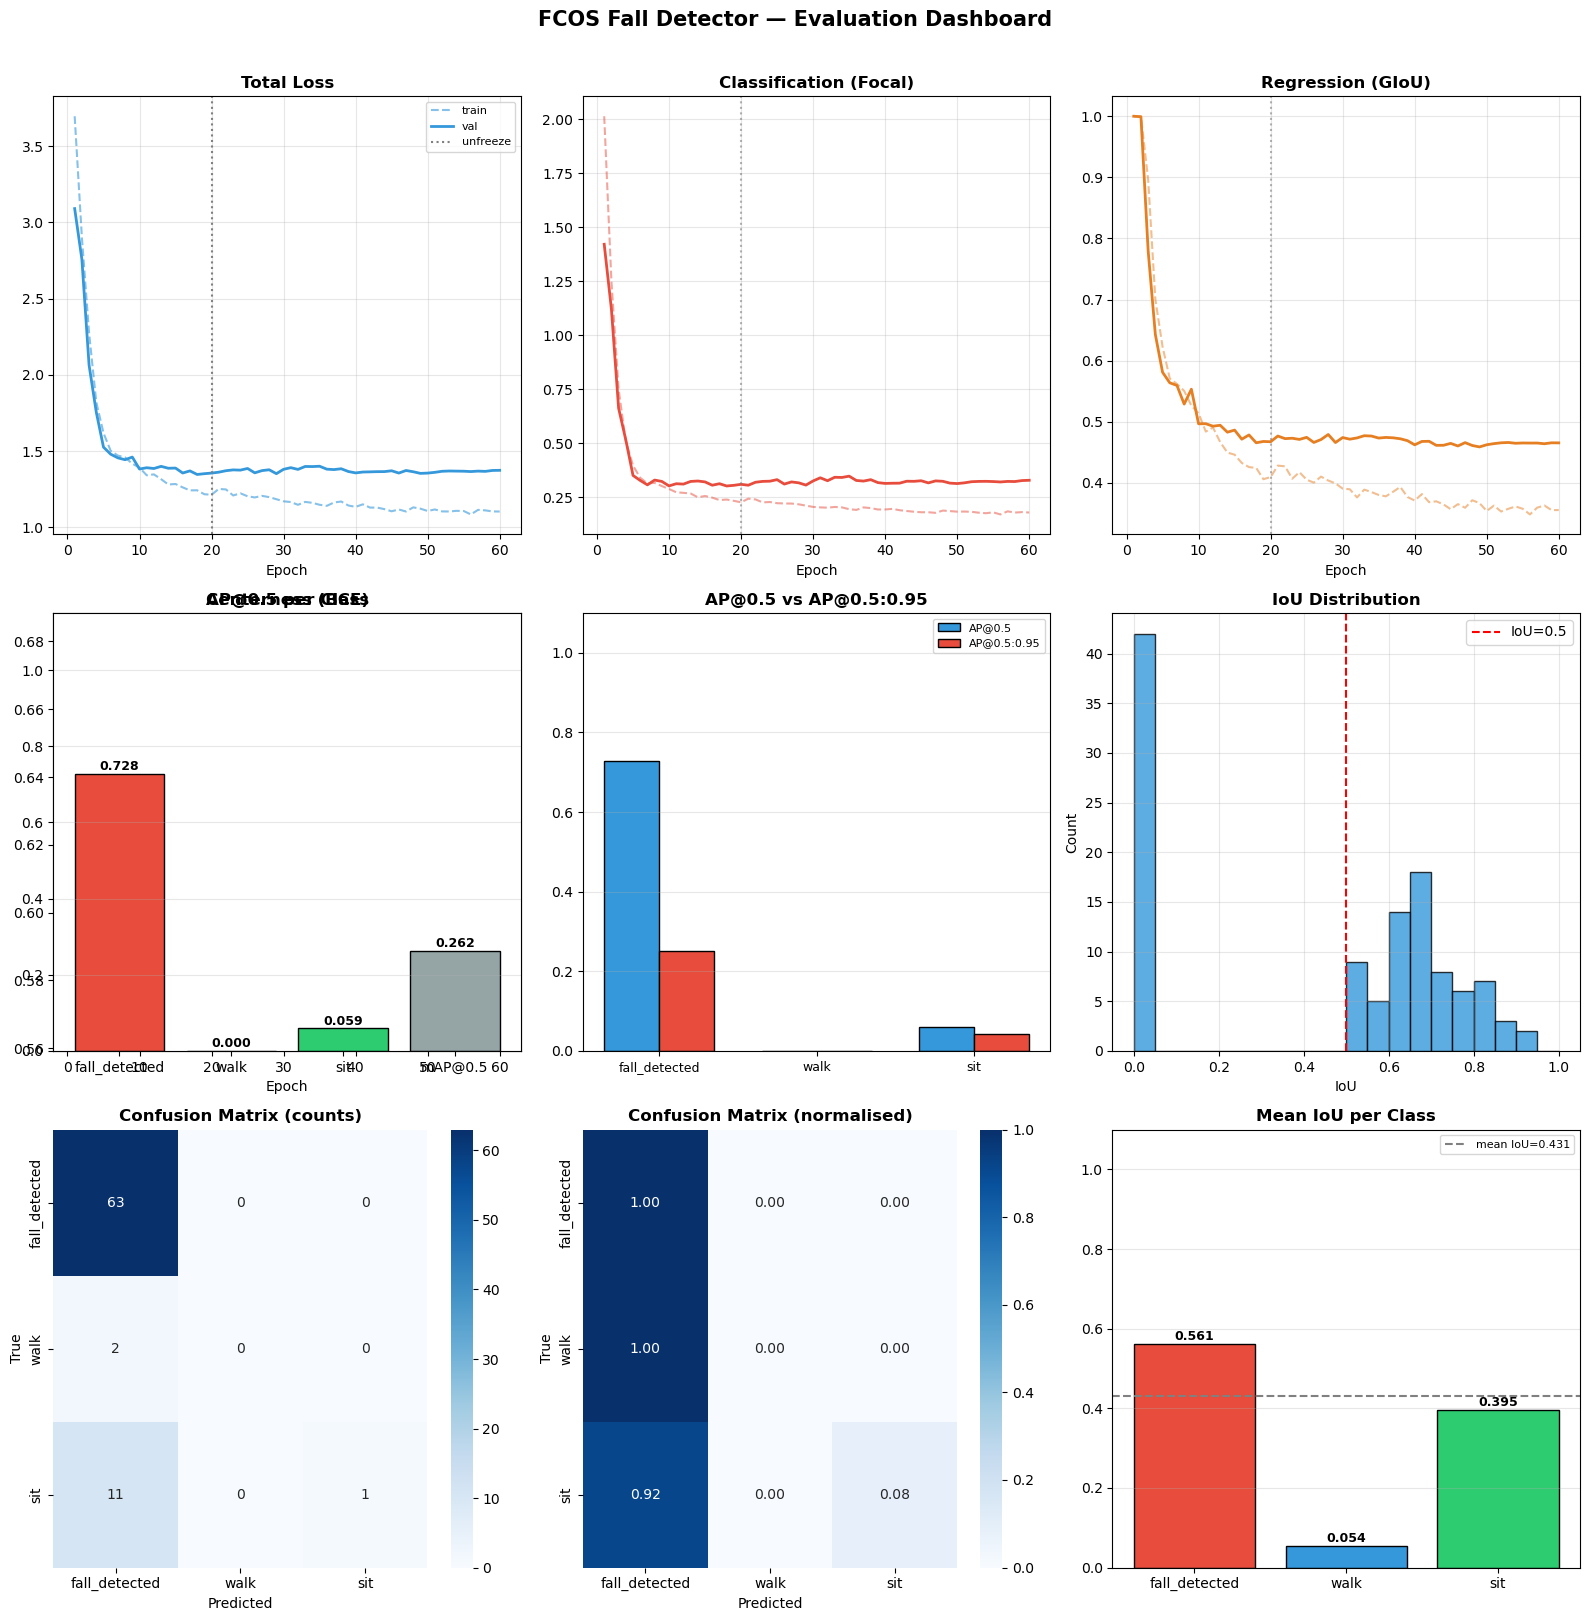


  Final Summary
  mAP@0.5        : 0.2625
  mAP@0.5:0.95   : 0.0974
  Mean IoU       : 0.4308
  Box Error Rate : 0.3684
  Class             AP@0.5  AP@.5:.95     mIoU
  ---------------------------------------------
  fall_detected     0.7281     0.2507   0.5606
  walk              0.0000     0.0000   0.0540
  sit               0.0594     0.0416   0.3950


In [12]:
# ── Evaluation Dashboard ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 16))
fig.suptitle('FCOS Fall Detector — Evaluation Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

ep = range(1, len(history['train_total']) + 1)

# Row 1: loss curves
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(ep, history['train_total'], '--', color='#3498db', alpha=0.6, label='train')
ax1.plot(ep, history['val_total'],   '-',  color='#3498db', lw=2,     label='val')
ax1.axvline(UNFREEZE_AT, color='grey', linestyle=':', label='unfreeze')
ax1.set_title('Total Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

comp_map = {'cls': '#e74c3c', 'reg': '#e67e22', 'ctr': '#2ecc71'}
comp_titles = {'cls': 'Classification (Focal)',
               'reg': 'Regression (GIoU)',
               'ctr': 'Centerness (BCE)'}
for i, (comp, cc) in enumerate(comp_map.items(), start=2):
    ax = fig.add_subplot(3, 3, i)
    ax.plot(ep, history[f'train_{comp}'], '--', color=cc, alpha=0.5)
    ax.plot(ep, history[f'val_{comp}'],   '-',  color=cc, lw=2)
    ax.axvline(UNFREEZE_AT, color='grey', linestyle=':', alpha=0.6)
    ax.set_title(comp_titles[comp], fontweight='bold')
    ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)

# Row 2: mAP bars
ax5 = fig.add_subplot(3, 3, 4)
bar_colors = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']
vals50 = [ap50[c] for c in range(NUM_CLASSES)] + [mAP50]
bars = ax5.bar(CLASS_NAMES + ['mAP@0.5'], vals50,
               color=bar_colors, edgecolor='black')
for bar, v in zip(bars, vals50):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax5.set_ylim(0, 1.15); ax5.set_title('AP@0.5 per Class', fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

ax6 = fig.add_subplot(3, 3, 5)
x = np.arange(NUM_CLASSES); w = 0.35
ax6.bar(x-w/2, [ap50[c]   for c in range(NUM_CLASSES)], w,
        label='AP@0.5',      color='#3498db', edgecolor='black')
ax6.bar(x+w/2, [ap5095[c] for c in range(NUM_CLASSES)], w,
        label='AP@0.5:0.95', color='#e74c3c', edgecolor='black')
ax6.set_xticks(x); ax6.set_xticklabels(CLASS_NAMES, fontsize=9)
ax6.set_ylim(0, 1.1); ax6.set_title('AP@0.5 vs AP@0.5:0.95', fontweight='bold')
ax6.legend(fontsize=8); ax6.grid(axis='y', alpha=0.3)

# IoU histogram
ax7 = fig.add_subplot(3, 3, 6)
ax7.hist(all_ious, bins=20, range=(0,1), color='#3498db',
         edgecolor='black', alpha=0.8)
ax7.axvline(0.5, color='red', linestyle='--', lw=1.5, label='IoU=0.5')
ax7.set_title('IoU Distribution', fontweight='bold')
ax7.set_xlabel('IoU'); ax7.set_ylabel('Count')
ax7.legend(); ax7.grid(alpha=0.3)

# Confusion matrices
ax8 = fig.add_subplot(3, 3, 7)
ax9 = fig.add_subplot(3, 3, 8)
if y_true:
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax8, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax8.set_title('Confusion Matrix (counts)', fontweight='bold')
    ax8.set_xlabel('Predicted'); ax8.set_ylabel('True')

    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax9, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, vmin=0, vmax=1)
    ax9.set_title('Confusion Matrix (normalised)', fontweight='bold')
    ax9.set_xlabel('Predicted'); ax9.set_ylabel('True')
else:
    for ax in [ax8, ax9]:
        ax.text(0.5, 0.5, 'No matched pairs\n(lower conf_thresh)',
                ha='center', va='center', transform=ax.transAxes)

# Per-class IoU
ax10 = fig.add_subplot(3, 3, 9)
iou_vals = [cls_iou.get(c, 0.0) for c in range(NUM_CLASSES)]
bars = ax10.bar(CLASS_NAMES, iou_vals,
                color=['#e74c3c','#3498db','#2ecc71'], edgecolor='black')
for bar, v in zip(bars, iou_vals):
    ax10.text(bar.get_x()+bar.get_width()/2,
              bar.get_height()+0.01,
              f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax10.axhline(mean_iou, color='grey', linestyle='--',
              label=f'mean IoU={mean_iou:.3f}')
ax10.set_ylim(0, 1.1)
ax10.set_title('Mean IoU per Class', fontweight='bold')
ax10.legend(fontsize=8); ax10.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fcos_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"="*50}')
print(f'  Final Summary')
print(f'{"="*50}')
print(f'  mAP@0.5        : {mAP50:.4f}')
print(f'  mAP@0.5:0.95   : {mAP5095:.4f}')
print(f'  Mean IoU       : {mean_iou:.4f}')
print(f'  Box Error Rate : {box_err:.4f}')
print(f'  {"Class":<15} {"AP@0.5":>8} {"AP@.5:.95":>10} {"mIoU":>8}')
print(f'  {"-"*45}')
for c, name in enumerate(CLASS_NAMES):
    print(f'  {name:<15} {ap50[c]:>8.4f} {ap5095[c]:>10.4f} {cls_iou.get(c,0):>8.4f}')
print(f'{"="*50}')

## 9. Qualitative Predictions

In [ ]:
BOX_COLORS = {'fall_detected': 'red', 'walk': 'lime', 'sit': 'cyan'}
test_imgs  = list((IMG_DIR / 'val').glob('*.jpg'))[:8]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
model.eval()

for ax, img_path in zip(axes, test_imgs):
    img_pil = Image.open(img_path).convert('RGB')
    tensor  = INFER_TF(img_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        cls_out, reg_out, ctr_out = model(tensor)

    dets = decode_fcos(
        cls_out[0].cpu(), reg_out[0].cpu(), ctr_out[0].cpu(),
        stride=STRIDE, img_size=IMG_SIZE,
        conf_thresh=0.25, nms_thresh=0.4
    )

    lb_img = LetterboxResize(IMG_SIZE)(img_pil)
    lW, lH = lb_img.size
    ax.imshow(lb_img)

    for det in dets:
        x1, y1, x2, y2 = det['box']
        name  = CLASS_NAMES[det['class']]
        color = BOX_COLORS.get(name, 'white')
        rect  = patches.Rectangle(
            (x1*lW, y1*lH), (x2-x1)*lW, (y2-y1)*lH,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1*lW, y1*lH - 4,
                f'{name} {det["score"]:.2f}',
                color=color, fontsize=7, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.4, pad=1))

    ax.set_title(img_path.name, fontsize=7)
    ax.axis('off')

plt.suptitle('FCOS Fall Detector — Predictions\n'
             '(red=fall  green=walk  cyan=sit)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fcos_predictions.png', dpi=150, bbox_inches='tight')
plt.show()